# Lecture 7 — Heatmap & Waterfall Charts

> **Dataset:** Netflix Content Catalogue - Source: [Kaggle](https://kaggle.com/datasets/shivamb/netflix-shows)

> **Source of figures:** Knaflic, C. N. (2015). *Storytelling with data*. Wiley


---
## Opening: Model Answer Review 

---
## Design Principles - Part I: Storytelling


### Why story sticks

> 💡 **Can you recall the story of Red Riding Hood? Most of you can — even if you last heard it 20 years ago. Now: can you recall the bullet points from the last presentation you sat through? Probably not** 

> 💡 **Data presented as facts is not memorable. Data embedded in a story is**


### The three-act structure applied to data

| Act | Question | In data terms |
|---|---|---|
| Setup (beginning) | What is the situation? What did we expect? | Here is the context and the baseline |
| Conflict (middle) | What changed? What is the problem? | Here is what the data shows — and why it matters |
| Resolution (end) | What do we recommend? | Here is the action we are asking for |



### Bing, Bang, Bongo

> 💡 **Tell your audience what you are going to tell them. Tell them. Tell them what you just told them. This feels repetitive — but it is how information sticks. Audiences appreciate having their expectations set, met, and confirmed**

- **Bing:** executive summary at the start — here is the Big Idea
- **Bang:** the data, the evidence, the charts
- **Bongo:** summary slide — here is what you just saw and what to do


---
## Design Principles - Part II: Heatmap + Waterfall Design

**Heatmap:**
- Use when you have two categorical axes and one numeric variable
- Pattern across the matrix is visible instantly (preattentive)
- Colour scale should be appropriate: sequential for ordered data, diverging for above/below average
- Always include a colour legend; always title the axes

>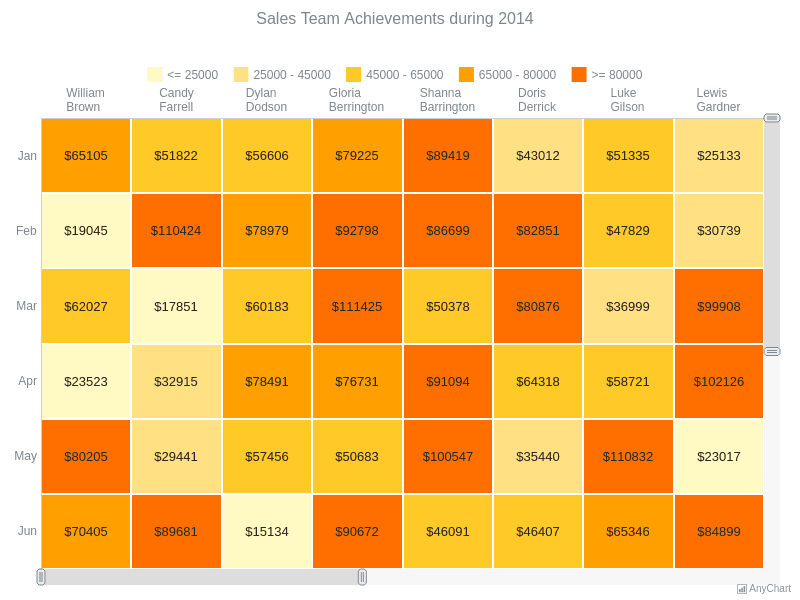

**Waterfall chart:**
- Shows how a value builds up or breaks down step by step
- Classic use: starting value → additions → subtractions → ending value
- Colour: green for positive contributions, red for negative, blue for totals
- Useful for budget analysis, headcount changes, revenue bridge

>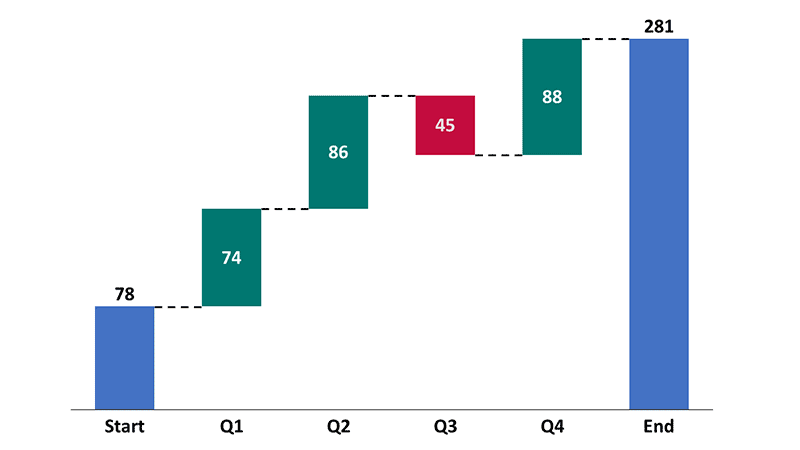

---
## Let's Code Some Examples 💻 


In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go



df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
df.head()


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64


,type,release_year,added_year,genre,country,rating,duration
0,Movie,2014,2016,Sci-Fi & Fantasy,France,PG-13,157
1,Movie,2010,2014,Documentaries,United States,TV-MA,127
2,TV Show,2011,2012,Kids & Family,United States,TV-14,6
3,Movie,2016,2018,Anime,India,PG,134
4,Movie,2014,2016,Kids & Family,Canada,TV-MA,77


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          3000 non-null   object
 1   release_year  3000 non-null   int64 
 2   added_year    3000 non-null   int64 
 3   genre         3000 non-null   object
 4   country       3000 non-null   object
 5   rating        3000 non-null   object
 6   duration      3000 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 164.2+ KB


### Example 1 — Heatmap: content by genre and year

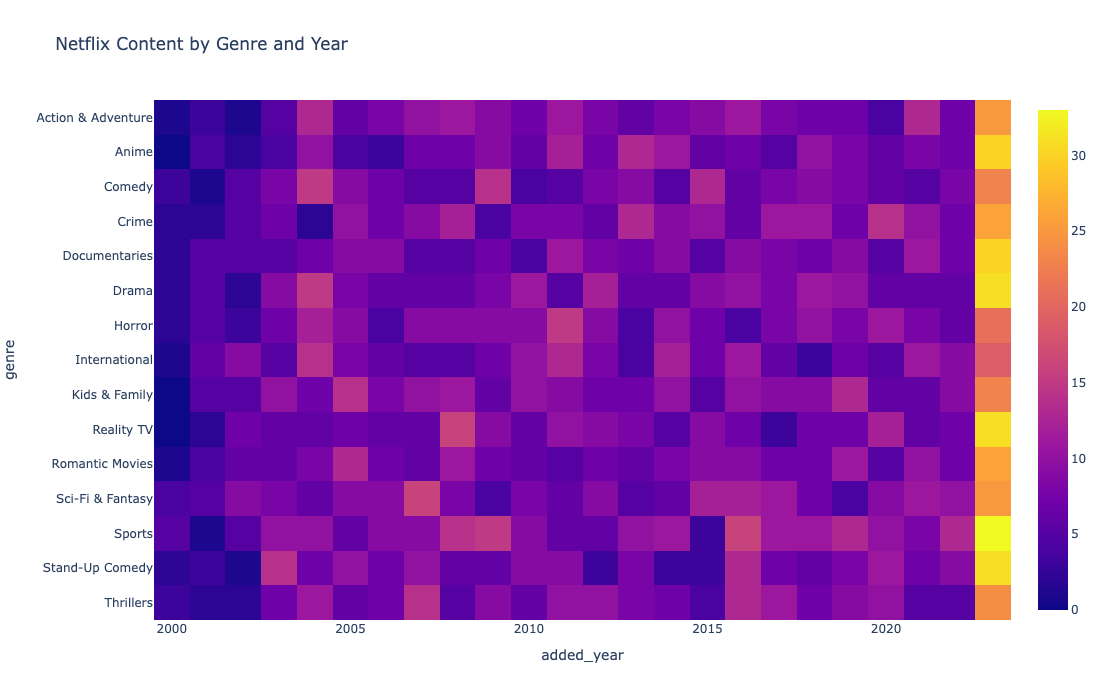

In [6]:
# exploratory: count of movies by genre over the years

genre_year = df.groupby(['genre','added_year']).size().reset_index(name='count')
pivot = genre_year.pivot(index='genre', columns='added_year', values='count').fillna(0)

fig = px.imshow(pivot, 
                title='Netflix Content by Genre and Year', 
               width=1000, height=700)
fig.show()



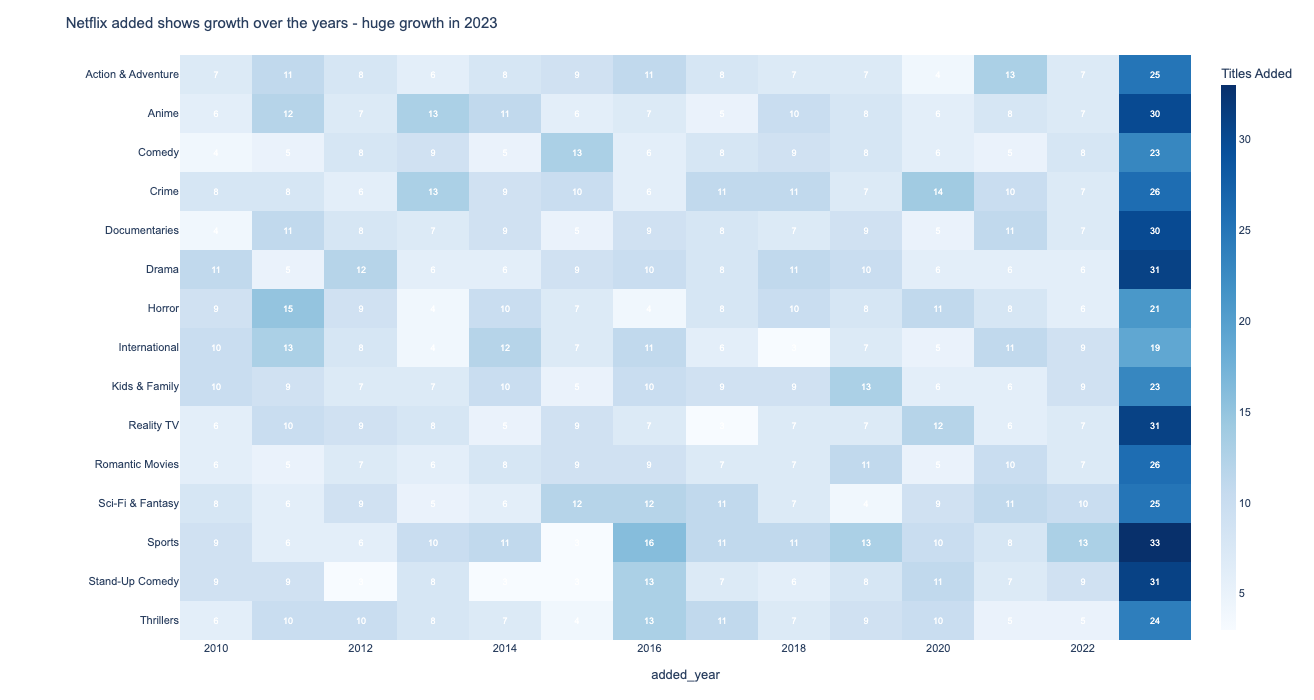

In [12]:
# Let's improve it!

# too many columns, filter to the part of the data you are interested in
recent = df.loc[df['added_year'] >= 2010]
genre_year = recent.groupby(['genre', 'added_year']).size().reset_index(name='count')
pivot = genre_year.pivot(index='genre', columns='added_year', values='count').fillna(0)



# ── Step 1: Plotly Express base chart ─────────────────────────────────────────
fig = px.imshow(
    pivot,
    color_continuous_scale='Blues',    # sequential one-color
    #aspect='auto',                     # let the chart fill the space naturally
    labels={'color': 'Titles Added'},
    text_auto=True,                    # show count value inside each cell
    height=700, width=1200
)

# ── Step 2: Customisation ─────────────────────────────────────────────────────
fig.update_traces(
    textfont=dict(size=9, color='white'),   # white text readable on dark cells
    hovertemplate='<b>%{y}</b> — %{x}<br>Titles: %{z}<extra></extra>',
)

fig.update_layout(
    title='Netflix added shows growth over the years - huge growth in 2023',
    font=dict(family='Arial', size=11),
    coloraxis_colorbar=dict(title='Titles Added', thickness=15),
    margin=dict(l=180, r=40, t=55, b=60),
    #coloraxis_showscale=False
)


fig.update_yaxes(title='')

fig.show()

### Example 2 — Heatmap: content by country and genre (annotated)

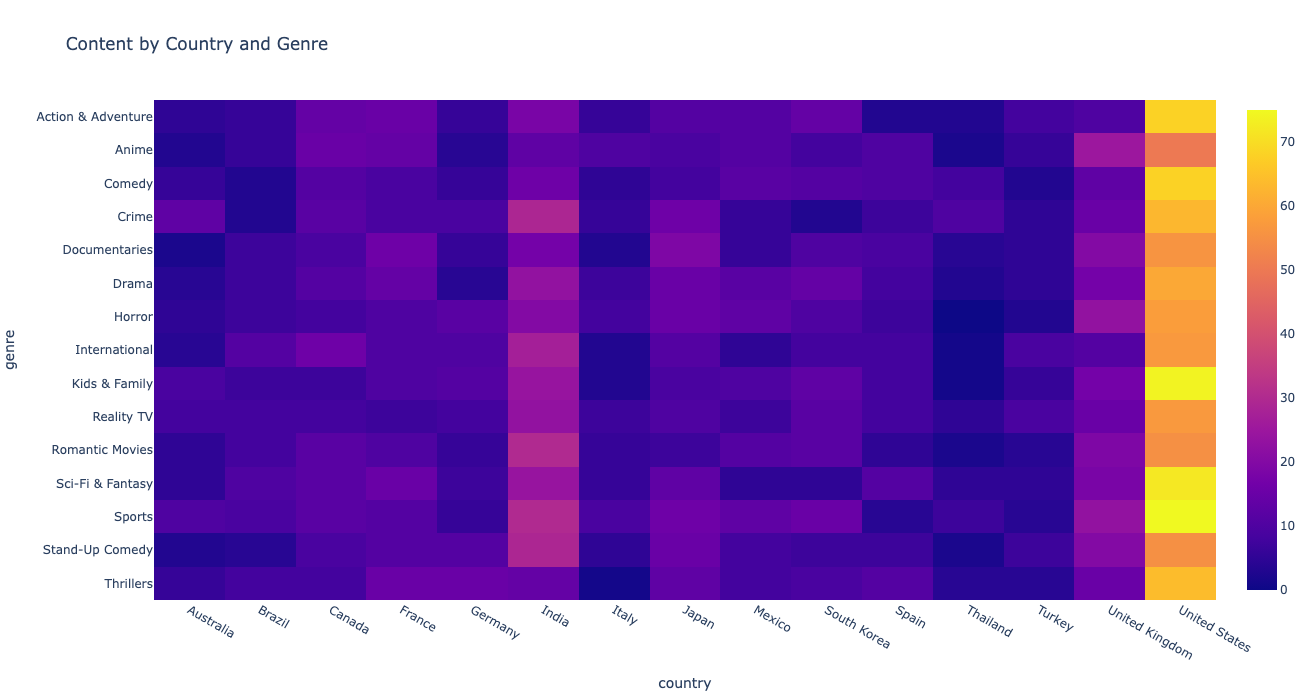

In [13]:
# exploratory

cg = df.groupby(['country','genre']).size().reset_index(name='count')
pivot2 = cg.pivot(index='genre', columns='country', values='count').fillna(0)

fig = px.imshow(pivot2, 
                title='Content by Country and Genre', 
                width=1100, height=700, aspect='auto')
fig.show()
# Too many genres — unreadable. Need to filter.


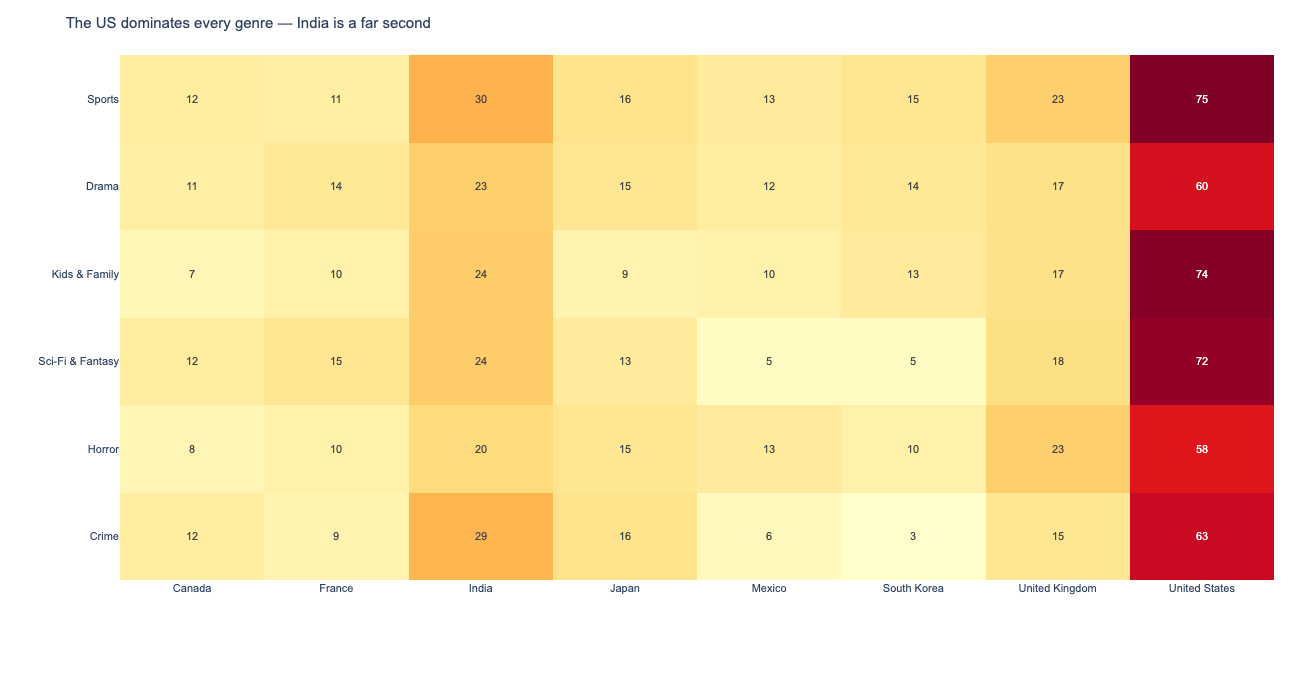

In [15]:
# Let's improve it

top_genres = df['genre'].value_counts().nlargest(6).index.tolist()
top_countries = df['country'].value_counts().nlargest(8).index.tolist()

cg_filtered = (df.loc[df['genre'].isin(top_genres) & df['country'].isin(top_countries)]
               .groupby(['country','genre']).size().reset_index(name='count'))
pivot3 = cg_filtered.pivot(index='genre', columns='country', values='count').fillna(0)

# Sort by total production
pivot3 = pivot3.loc[pivot3.sum(axis=1).sort_values(ascending=False).index]

fig = px.imshow(
    pivot3,
    text_auto=True,                    
    color_continuous_scale='YlOrRd',   # yellow-orange-red: low to high chosen here to be 2-color to highlight the US
    aspect='auto', width=1100, height=700
)
fig.update_layout(
    title='The US dominates every genre — India is a far second',
    font=dict(family='Arial', size=11),
    coloraxis_showscale=False,         # values in cells make colorbar redundant
    margin=dict(l=120, r=40, t=55, b=120),
    xaxis=dict(title=''),
    yaxis=dict(title='')
)
fig.show()


### Example 3 — Waterfall chart: content additions by year

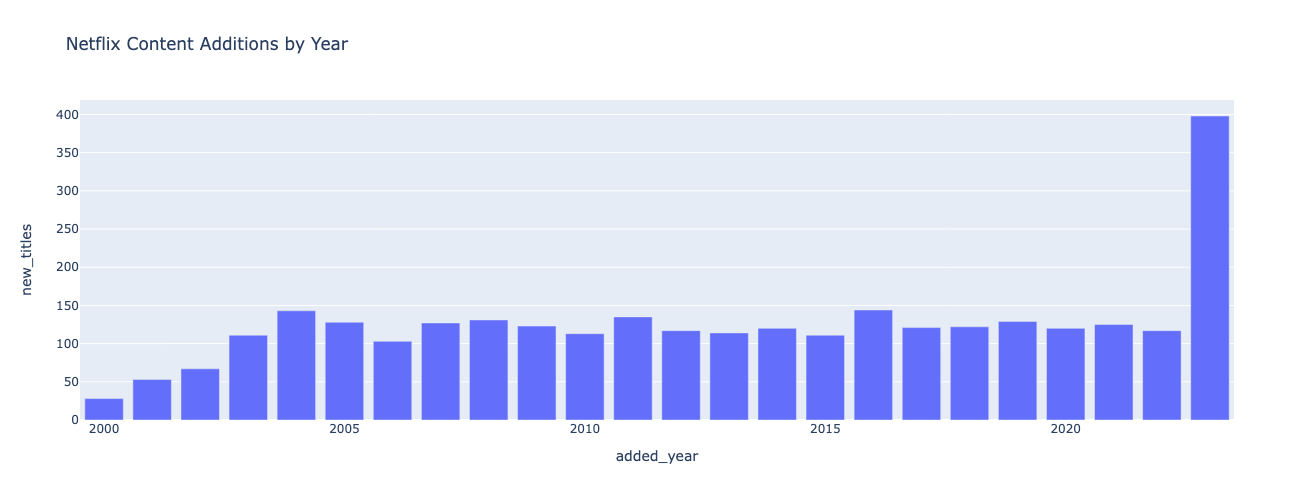

In [17]:
# exploratory

adds = df.groupby('added_year').size().reset_index(name='new_titles')
fig = px.bar(adds, x='added_year', y='new_titles',
             title='Netflix Content Additions by Year',
            height=500)
fig.show()


### `go.Waterfall` — key arguments

`go.Waterfall` is not available in Plotly Express — it must be built with Graph Objects directly.

**Core arguments:**

- **`x`** — category labels for each bar, passed as a list of strings
- **`y`** — the value of each bar, passed as a list of numbers
- **`measure`** — controls how each bar is drawn; one string per bar (see below)
- **`text`** — list of labels shown above each bar; pass pre-computed values since `texttemplate` only has access to the bar's own `y`, not the running total
- **`textposition`** — `'outside'` places labels above bars; `'inside'` places them within
- **`connector`** — the dotted line connecting the top of one bar to the base of the next; set `line=dict(color=..., dash='dot')`
- **`increasing`** — colour settings for positive `'relative'` bars: `dict(marker_color='...')`
- **`decreasing`** — colour settings for negative `'relative'` bars (e.g. cancellations, refunds)
- **`totals`** — colour settings for `'total'` bars: `dict(marker_color='...')`

**The `measure` list — the most important argument:**

Each string in the list maps to one bar:

| Value | Behaviour | When to use |
|---|---|---|
| `'absolute'` | Bar starts from zero | Opening baseline / starting reference |
| `'relative'` | Bar stacks on top of the previous bar's endpoint | Incremental additions or subtractions |
| `'total'` | Bar drops back to zero and shows the full cumulative height | Final summary bar |


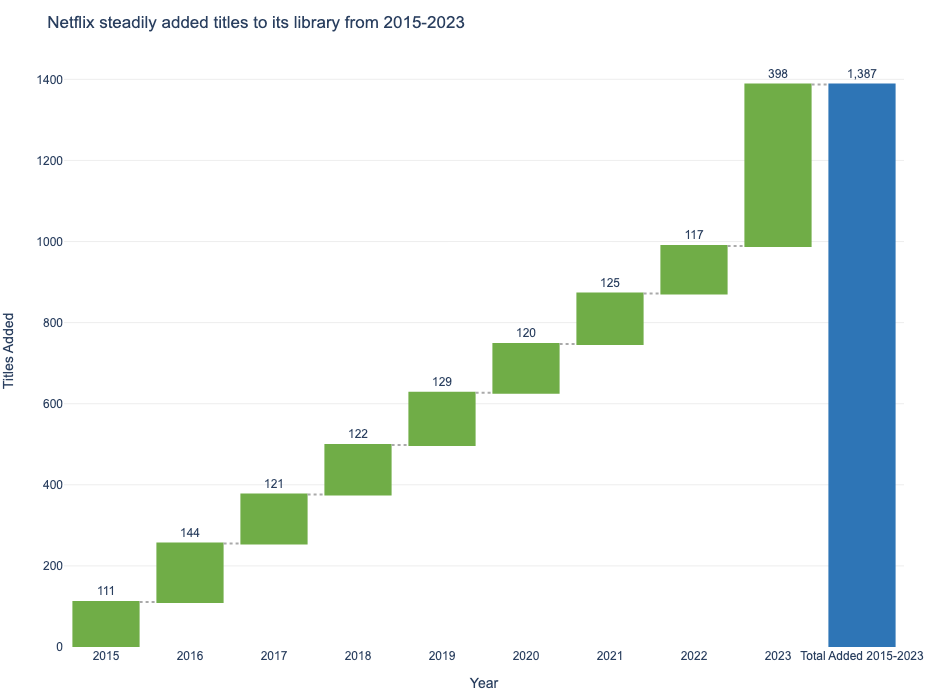

In [32]:
# constructing a waterfall without starting from absolute and with total in the end

adds = df.groupby('added_year').size().reset_index(name='new_titles')
adds = adds.loc[adds['added_year'] >= 2015].copy()

# Calculate cumulative total as final bar
cumulative = adds['new_titles'].sum()

# Waterfall is currently still not in plotly express

trace = go.Waterfall(
    x=adds['added_year'].astype(str).tolist() + ['Total Added 2015-2023'],  # building x-ticks labels
    y=adds['new_titles'].tolist() + [cumulative],                     # building y-ticks labels
    measure=['relative']*len(adds) + ['total'],   # relative = bars stack; total = final sum
    connector=dict(line=dict(color='#AAAAAA', dash='dot')),
    increasing=dict(marker_color='#70AD47'),       # green for additions (positive)
    totals=dict(marker_color='#2E75B6'),           # blue for the total bar
    texttemplate='%{y:,}',                         # shows the y values as annotation
    textposition='outside'
)

my_data = [trace]
fig = go.Figure(data=my_data)

fig.update_layout(
    title='Netflix steadily added titles to its library from 2015-2023',
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    yaxis=dict(gridcolor='#EEEEEE', title='Titles Added'),
    xaxis=dict(title='Year', showgrid=False),
    margin=dict(l=60, r=40, t=55, b=40),
    showlegend=False,
    height=700
)
fig.show()


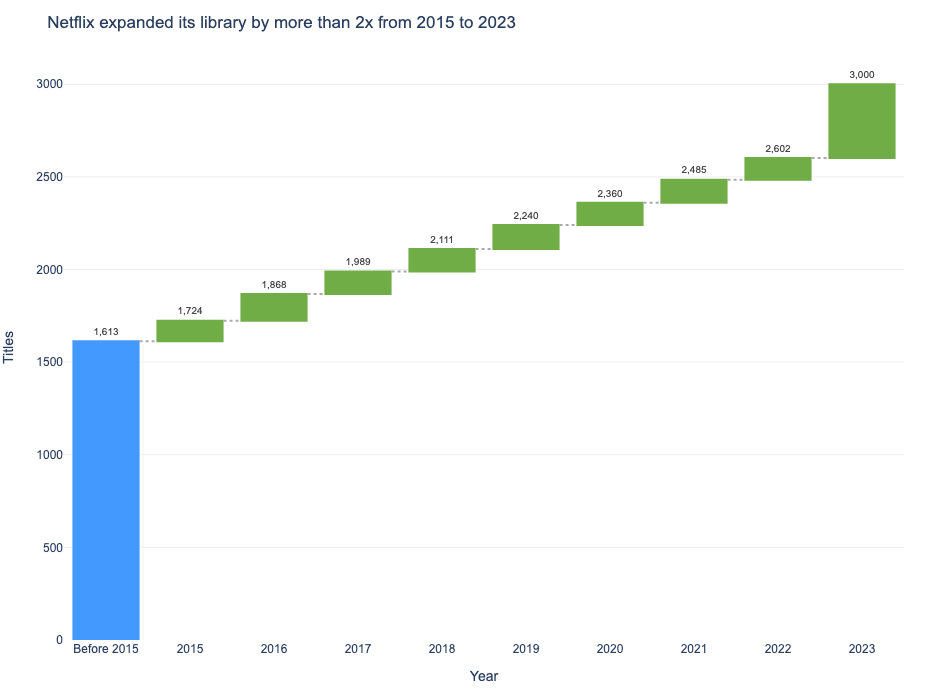

In [34]:
# another way to construct the waterfall with absolute in the beginning and total here does not make sense


# ── Data prep ─────────────────────────────────────────────────────────────────
adds = df.groupby('added_year').size().reset_index(name='new_titles')
adds = adds.loc[adds['added_year'] >= 2015].copy()

titles_before_2015 = df[df['added_year'] < 2015].shape[0]

# Running cumulative total starting from the baseline
cumulative_totals = (
    [titles_before_2015] +
    (titles_before_2015 + adds['new_titles'].cumsum()).tolist()
)

x_vals  = ['Before 2015'] + adds['added_year'].astype(str).tolist()
y_vals  = [titles_before_2015] + adds['new_titles'].tolist()
measure = ['absolute'] + ['relative'] * len(adds)
# No 'total' bar — removed

# ── Chart ─────────────────────────────────────────────────────────────────────
trace = go.Waterfall(
    x=x_vals,
    y=y_vals,
    measure=measure,
    text=[f'{v:,}' for v in cumulative_totals],   # running total as annotation
    textposition='outside',
    connector=dict(line=dict(color='#AAAAAA', dash='dot')),
    increasing=dict(marker_color='#70AD47'),
    textfont=dict(size=10, color='#444444'),
)

fig = go.Figure(data=[trace])

# ── Customisation ─────────────────────────────────────────────────────────────
fig.update_layout(
    title='Netflix expanded its library by more than 2x from 2015 to 2023',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    showlegend=False,
    margin=dict(l=60, r=40, t=55, b=60),
    height=700,
)
fig.update_xaxes(title='Year', showgrid=False)
fig.update_yaxes(title='Titles', gridcolor='#EEEEEE')

fig.show()

---
## Class Exercise 💪 💻